In [2]:
import torch
import torch.nn as nn
import numpy as np
from sklearn import datasets
import matplotlib.pyplot as plt

epoch: 1, loss: 5635.8701
epoch: 11, loss: 502.6278
epoch: 21, loss: 338.3634
epoch: 31, loss: 332.7691
epoch: 41, loss: 332.5746
epoch: 51, loss: 332.5678
epoch: 61, loss: 332.5676
epoch: 71, loss: 332.5675
epoch: 81, loss: 332.5675
epoch: 91, loss: 332.5675


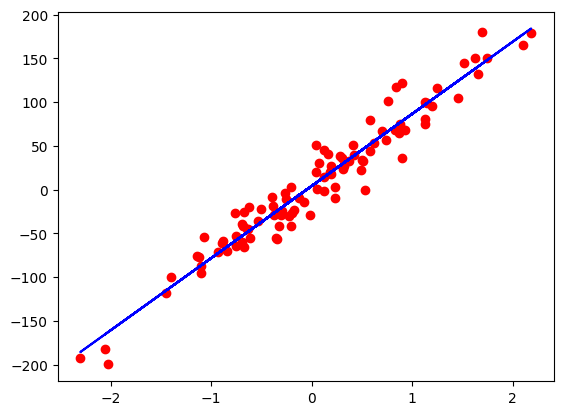

In [5]:
#1) prepare the data
x_numpy, y_numpy = datasets.make_regression(n_samples=100, n_features=1, noise=20, random_state=1)

x = torch.from_numpy(x_numpy.astype(np.float32))
y = torch.from_numpy(y_numpy.astype(np.float32))
y = y.view(y.shape[0], 1)

n_samples, n_features = x.shape

#2) model
input_size = n_features
output_size = 1

model = nn.Linear(input_size, output_size)

#3) loss and optimizer
learning_rate = 0.1
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

#4) training loop
num_epochs = 100
for epoch in range(num_epochs):
  #forward pass and loss
  y_predicted = model(x)
  loss = criterion(y_predicted, y)

  #backpropagation
  loss.backward()

  #gradient descent
  optimizer.step()

  #restart gradeints for next iteration
  optimizer.zero_grad()

  if epoch % 10 == 0:
    print(f'epoch: {epoch+1}, loss: {loss.item():.4f}')

#5) plot
#detach this operation from the computation graph
predicted = model(x).detach().numpy()
plt.plot(x_numpy, y_numpy, 'ro')
plt.plot(x_numpy, predicted, 'b')
plt.show()